# Visualisation of Parcels surface movement for each Turn Point simulation

In [1]:
import os
import xarray as xr
import numpy as np
import geopandas as gpd
from pathlib import Path
from PIL import Image
import glob
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from shapely.geometry import Point
import ssam_groups as groups
from IPython.display import Image as im

In [2]:
scenario = "5b_TurnPoint_Dilbit"

In [4]:
scen_path = Path('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/MPRI2-zarr')
scens = sorted([p for p in scen_path.glob(scenario+'*.zarr')])
scens

[PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/MPRI2-zarr/5b_TurnPoint_Dilbit_2019-01-20_10000_OP_D50_wp3.zarr'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/MPRI2-zarr/5b_TurnPoint_Dilbit_2019-04-12_10000_OP_D50_wp3.zarr'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/MPRI2-zarr/5b_TurnPoint_Dilbit_2019-07-03_10000_OP_D50_wp3.zarr'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/MPRI2-zarr/5b_TurnPoint_Dilbit_2019-10-20_10000_OP_D50_wp3.zarr'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/MPRI2-zarr/5b_TurnPoint_Dilbit_2020-01-24_10000_OP_D50_wp3.zarr'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/MPRI2-zarr/5b_TurnPoint_Dilbit_2020-04-11_10000_OP_D50_wp3.zarr'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/n

In [5]:
scenario_code = 'TP-'
hex_colour = '#6DB48E'

In [6]:
# salish sea atlantis box shapefile.
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
data_df_original = data_df_original.sort_values(by=['BOX_ID'])
data_df = data_df_original.set_index('BOX_ID')
box_depth = data_df['BOTZ']
box_area = data_df['AREA']
land_boxes = box_depth==0
land_boxes = data_df.index[land_boxes]

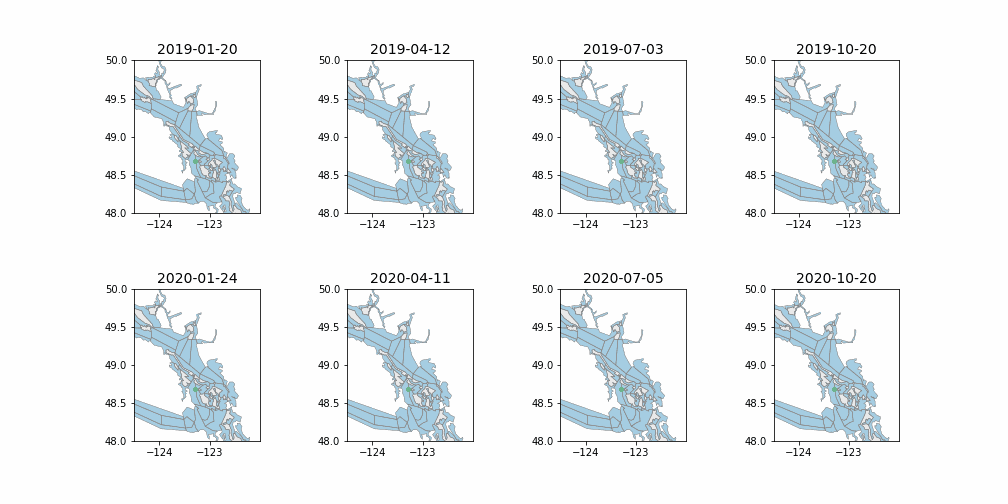

In [13]:
#All time steps in DAY 1
_cmap = cm.Paired
land_df = data_df.loc[land_boxes]

file_names = []

for time_index in range(0, 24):
    
    fig, axs = plt.subplots(2, 4, figsize=(14, 7), facecolor='white', gridspec_kw={'wspace': 0.5, 'hspace': 0.5})
    axs = axs.flatten()
    #fig = plt.figure(figsize=(14, 6), facecolor='white') #figsize=(9, 12)
    #gs = plt.GridSpec(1, 4, wspace=0.5, hspace=0.5, height_ratios=[1],)
    for ax, path in zip(axs, scens):
        date = str(path).split(sep = '_')[3]
        label = date
        #ax = fig.add_subplot(gs[0, position])
        data_df.plot(column = 'vertmix', cmap=_cmap, ax=ax,
        vmin=0, vmax = 10,
        legend=False,
        )
        land_df.plot(ax=ax, color='white')

        pfile = xr.open_zarr(str(path))

        lon = pfile.variables['lon']
        lat = pfile.variables['lat']

        plon = lon[:, time_index]
        plat = lat[:, time_index]

        ax.scatter(plon, plat, s=10, zorder=20, c=hex_colour) #s=0.001
        ax.set_title(label, fontsize = 14) #loc='left'
        ax.set_xlim(-124.5)
        ax.set_ylim(48, 50)
        data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
        land_df.plot(ax=ax, color='#EBEBEB')

    #plt.tight_layout()
    plot_name = 'particles_at_time_' + str(time_index).zfill(3) + '.png'
    plt.savefig(plot_name)
    file_names.append(plot_name)
    plt.close()

# Create the frames
frames = []
imgs = glob.glob("particles_at_time*.png")
imgs.sort() 
for i in imgs:
    new_frame = Image.open(i)
    frames.append(new_frame)


# Save into loop
anim_name = 'Particle_trajectory_MPRI2_' + scenario +'.gif'
frames[0].save(anim_name, format='GIF',
               append_images=frames[1:],
               save_all=True,
               duration=300, loop=0)

file_name_str = ' '.join(file_names)
os.system('rm ' + file_name_str)

# Plot image
with open(anim_name,'rb') as anim:
    display(im(anim.read()))

In [ ]:
# Create the frames
frames = []
imgs = glob.glob("particles_at_time*.png")
imgs.sort() 
for i in imgs:
    new_frame = Image.open(i)
    frames.append(new_frame)

# Save into loop
anim_name = 'Particle_trajectory_MPRI2_' + scenario +'.gif'
frames[0].save(anim_name, format='GIF',
               append_images=frames[1:],
               save_all=True,
               duration=300, loop=0)

file_name_str = ' '.join(file_names)
os.system('rm ' + file_name_str)

# Plot image
with open(anim_name,'rb') as anim:
    display(im(anim.read()))

## Animation using only Atlantis 12-hour time-step

In [15]:
#Full 10-day simulation (no containment)
_cmap = cm.Paired
land_df = data_df.loc[land_boxes]

pfile = xr.open_zarr(scens[0])
time_slice = np.arange(0,len(pfile.time[0]),12) #or any N
reduced_pfile = pfile.isel(obs=(time_slice))

numObs_reduced = time_slice.size
TP_file_names = []

for time_index in range(0, numObs_reduced):

    fig, axs = plt.subplots(2, 4, figsize=(14, 7), facecolor='white', gridspec_kw={'wspace': 0.5, 'hspace': 0.5})
    axs = axs.flatten()

    for ax, path in zip(axs, scens):
        date = str(path).split(sep = '_')[3]
        label = date

        data_df.plot(column = 'vertmix', cmap=_cmap, ax=ax,
        vmin=0, vmax = 10,
        legend=False,
        )
        land_df.plot(ax=ax, color='white')

        pfile = xr.open_zarr(str(path))
        time_slice = np.arange(0,len(pfile.time[0]),12) #an array of times that correspond to Atlantis timesteps
        reduced_pfile = pfile.isel(obs=(time_slice))

        lon = reduced_pfile.variables['lon']
        lat = reduced_pfile.variables['lat']

        plon = lon[:, time_index]
        plat = lat[:, time_index]

        ax.scatter(plon, plat, s=10, zorder=20, c=hex_colour) #s=0.001
        ax.set_title(label, fontsize = 14) #loc='left'
        ax.set_xlim(-124.5)
        ax.set_ylim(48, 50)
        data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
        land_df.plot(ax=ax, color='#EBEBEB')

    #plt.tight_layout()
    plot_name = 'particles_at_time_' + str(time_index).zfill(3) + '.png'
    plt.savefig(plot_name)
    TP_file_names.append(plot_name)
    plt.close()

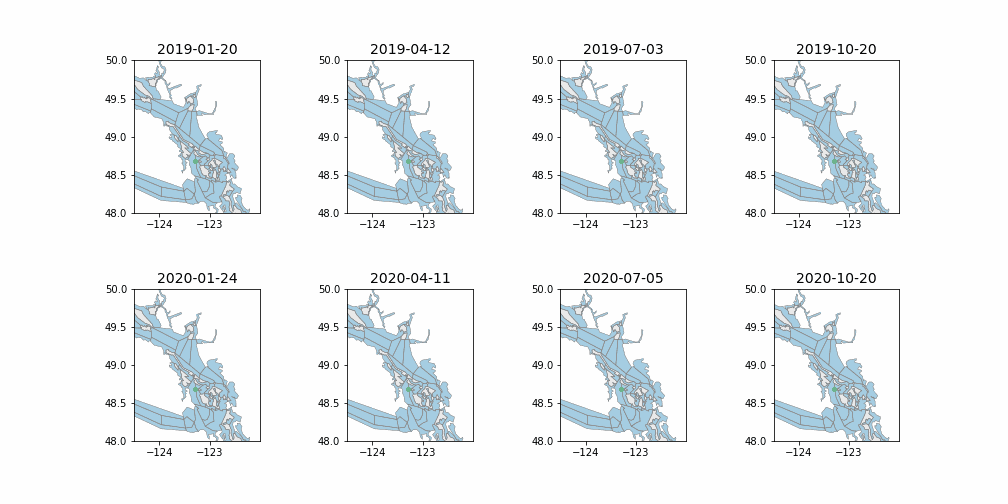

In [16]:
# Create the frames
frames = []
imgs = glob.glob("particles_at_time*.png")
imgs.sort() 
for i in imgs:
    new_frame = Image.open(i)
    frames.append(new_frame)


# Save into loop
anim_name = 'Particle_trajectory_MPRI2_' + scenario +'_reduced.gif'
frames[0].save(anim_name, format='GIF',
               append_images=frames[1:],
               save_all=True,
               duration=300, loop=0)

file_name_str = ' '.join(TP_file_names)
os.system('rm ' + file_name_str)

# Plot image
with open(anim_name,'rb') as anim:
    display(im(anim.read()))

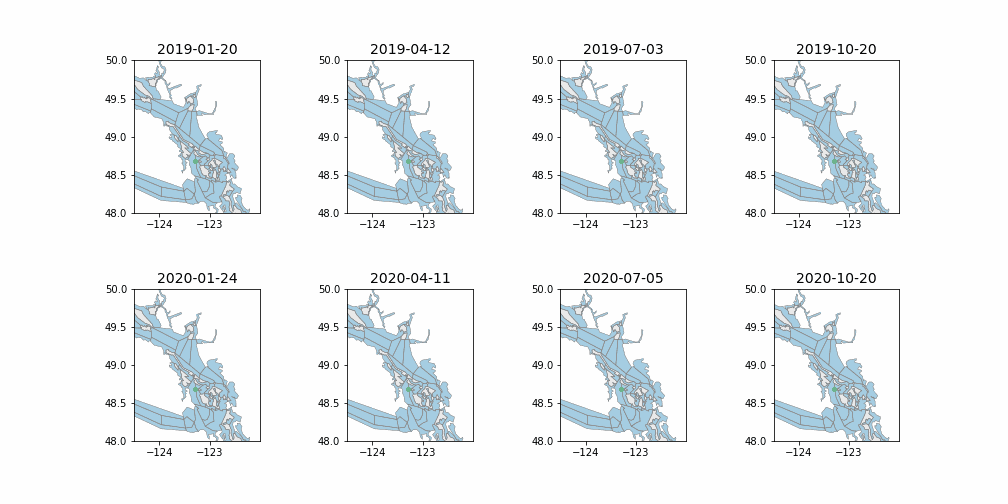

In [17]:
#48h simulation (assumed containment by 48 hours)
_cmap = cm.Paired
land_df = data_df.loc[land_boxes]

pfile = xr.open_zarr(scens[0])
time_slice = np.arange(0,len(pfile.time[0]),12) #or any N
reduced_pfile = pfile.isel(obs=(time_slice))

numObs_reduced = time_slice.size
TP_file_names = []

for time_index in range(0, 4):

    fig, axs = plt.subplots(2, 4, figsize=(14, 7), facecolor='white', gridspec_kw={'wspace': 0.5, 'hspace': 0.5})
    axs = axs.flatten()

    for ax, path in zip(axs, scens):
        date = str(path).split(sep = '_')[3]
        label = date

        data_df.plot(column = 'vertmix', cmap=_cmap, ax=ax,
        vmin=0, vmax = 10,
        legend=False,
        )
        land_df.plot(ax=ax, color='white')

        pfile = xr.open_zarr(str(path))
        time_slice = np.arange(0,len(pfile.time[0]),12) #an array of times that correspond to Atlantis timesteps
        reduced_pfile = pfile.isel(obs=(time_slice))

        lon = reduced_pfile.variables['lon']
        lat = reduced_pfile.variables['lat']

        plon = lon[:, time_index]
        plat = lat[:, time_index]

        ax.scatter(plon, plat, s=10, zorder=20, c=hex_colour) #s=0.001
        ax.set_title(label, fontsize = 14) #loc='left'
        ax.set_xlim(-124.5)
        ax.set_ylim(48, 50)
        data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
        land_df.plot(ax=ax, color='#EBEBEB')

    #plt.tight_layout()
    plot_name = 'particles_at_time_' + str(time_index).zfill(3) + '.png'
    plt.savefig(plot_name)
    TP_file_names.append(plot_name)
    plt.close()

# Create the frames
frames = []
imgs = glob.glob("particles_at_time*.png")
imgs.sort() 
for i in imgs:
    new_frame = Image.open(i)
    frames.append(new_frame)


# Save into loop
anim_name = 'Particle_trajectory_MPRI2_48hrs.gif'
frames[0].save(anim_name, format='GIF',
               append_images=frames[1:],
               save_all=True,
               duration=300, loop=0)

file_name_str = ' '.join(TP_file_names)
os.system('rm ' + file_name_str)

# Plot image
with open(anim_name,'rb') as anim:
    display(im(anim.read()))